# Importaciones

In [61]:
from pathlib import Path
import os

import pandas as pd
import duckdb
import psycopg
from datasketch import MinHash
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
import spacy
import spacy_ngram

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

load_dotenv()

True

In [62]:
DATABASE_URL = os.getenv("POSTGRES_URI")
pd.options.display.max_rows = 100
pd.options.display.max_seq_items = 300

In [3]:
# os.environ.pop('POSTGRES_URI', None)

# Prueba de conexión a base de datos

In [34]:
try:
    with psycopg.connect(conninfo=DATABASE_URL) as conn:
        print("✅ Conexión exitosa con psycopg3!")
        
        with conn.cursor() as cur:
            print("\nConsultando la tabla 'news_chile'...")
            cur.execute("SELECT * FROM news_chile LIMIT 1;")
            
            records = cur.fetchall()
            
            if not records:
                print("  La tabla 'news' está vacía.")
            else:
                for row in records:
                    print(f"  - {row}")

except psycopg.OperationalError as e:
    print(f"❌ Error de conexión: {e}\nPor favor, verifica la IP del Asus y que el Firewall permita el tráfico.")
except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

✅ Conexión exitosa con psycopg3!

Consultando la tabla 'news_chile'...
  - (158443, 'www.aricaldia.cl/tarifas-servel-2024', 'https://www.aricaldia.cl/alcalde-cristian-zavala-llama-a-construir-un-estado-inclusivo-con-las-comunas-rurales/', datetime.datetime(2024, 12, 7, 13, 24, 51), None, 'En la jornada de asunción de nuevas autoridades de la comuna, el alcalde de Camarones, Cristian Zavala Soto, asumió un nuevo período al frente del gobierno comunal con un llamado contundente: construir un Estado que incluya y valore el territorio rural.\n\nDurante la ceremonia de asunción, marcada por la diversidad cultural y espiritual, Zavala expresó la necesidad de que las decisiones del Estado comprendan las complejidades de las zonas rurales y se adapten a las características únicas de cada territorio.\n\n“La ruralidad no puede estar al margen de las políticas públicas; al contrario, debe ser el centro de las decisiones para cerrar las brechas de desigualdad. Cada rincón del territorio debe ser p

# Consultas de exploración

In [35]:
with psycopg.connect(conninfo=DATABASE_URL) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT count(body_hash) AS raw_count, count(DISTINCT body_hash) as deduplicated_count FROM news_chile LIMIT 2;")
        
        records = cur.fetchall()
        
        if not records:
            print("  La tabla 'news' está vacía.")
        else:
            for row in records:
                print(f"  - {row}")

  - (333762, 333762)


In [36]:
with psycopg.connect(conninfo=DATABASE_URL) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT date FROM news_chile LIMIT 10;")
        
        records = cur.fetchall()
        
        if not records:
            print("  La tabla 'news' está vacía.")
        else:
            for row in records:
                print(f"  - {row}")

  - (datetime.datetime(2024, 12, 7, 13, 24, 51),)
  - (datetime.datetime(2024, 12, 7, 2, 37, 43),)
  - (datetime.datetime(2024, 12, 7, 2, 19, 43),)
  - (datetime.datetime(2024, 12, 8, 0, 42, 2),)
  - (datetime.datetime(2024, 12, 7, 22, 1),)
  - (datetime.datetime(2024, 12, 8, 0, 52, 21),)
  - (datetime.datetime(2024, 12, 8, 0, 29, 13),)
  - (datetime.datetime(2024, 12, 7, 13, 12, 3),)
  - (datetime.datetime(2024, 12, 7, 0, 0),)
  - (datetime.datetime(2024, 12, 7, 0, 0),)


In [33]:
with psycopg.connect(conninfo=DATABASE_URL) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT EXTRACT(MONTH FROM date) as month, count(body_hash) FROM news_chile GROUP BY month;")
        
        records = cur.fetchall()
        
        if not records:
            print("  La tabla 'news' está vacía.")
        else:
            for row in records:
                print(f"  - {row}")

  - (None, 38447)
  - (Decimal('11'), 17880)
  - (Decimal('7'), 47630)
  - (Decimal('8'), 43324)
  - (Decimal('9'), 32812)
  - (Decimal('6'), 33974)
  - (Decimal('1'), 15082)
  - (Decimal('2'), 12483)
  - (Decimal('3'), 16545)
  - (Decimal('10'), 14202)
  - (Decimal('5'), 29528)
  - (Decimal('12'), 14516)
  - (Decimal('4'), 17339)


## Conexión con duckdb

In [3]:
con = duckdb.connect()
con.sql("INSTALL postgres;")
con.sql("LOAD postgres;")

db_uri = DATABASE_URL

# Adjuntar usando f-string para insertar la variable
con.sql(f"ATTACH '{db_uri}' AS news_db (TYPE postgres, READ_ONLY);")

# Realizar la consulta
resultado = con.sql("SELECT * FROM news_db.news_chile LIMIT 3").df()
print(resultado)

       id                            media_name  \
0  158443  www.aricaldia.cl/tarifas-servel-2024   
1  158444  www.aricaldia.cl/tarifas-servel-2024   
2  158445  www.aricaldia.cl/tarifas-servel-2024   

                                                 url                date  \
0  https://www.aricaldia.cl/alcalde-cristian-zava... 2024-12-07 13:24:51   
1  https://www.aricaldia.cl/160-anos-que-dan-cuen... 2024-12-07 02:37:43   
2  https://www.aricaldia.cl/embellecen-centro-de-... 2024-12-07 02:19:43   

  author                                               body  \
0   None  En la jornada de asunción de nuevas autoridade...   
1   None  Este 2024 la Educación Parvularia Pública en C...   
2   None  Iniciativa se logra gracias al Fondart Regiona...   

                          body_hash  
0  a64565a016c6f83bb420f1e22315053a  
1  76d2801fa43bed3899b076b8fc118232  
2  bdd267cd444b985a4fc0e10c0da34cde  


In [5]:
tablas = con.execute("SHOW TABLES FROM news_db;").fetchdf()
print(tablas.to_markdown())

|    | name                |
|---:|:--------------------|
|  0 | news_argentina      |
|  1 | news_bolivia        |
|  2 | news_chile          |
|  3 | news_colombia       |
|  4 | news_costa_rica     |
|  5 | news_ecuador        |
|  6 | news_espana         |
|  7 | news_estados_unidos |
|  8 | news_guatemala      |
|  9 | news_internacional  |
| 10 | news_mexico         |
| 11 | news_nicaragua      |
| 12 | news_panama         |
| 13 | news_peru           |
| 14 | news_religion       |
| 15 | news_rep_dominicana |
| 16 | news_tecnologia     |
| 17 | news_uruguay        |
| 18 | news_venezuela      |
| 19 | news_video_juegos   |


In [6]:
resultado = con.execute("DESCRIBE news_db.news_chile").fetchdf()

In [7]:
resultado

,column_name,column_type,null,key,default,extra
0,id,INTEGER,NO,PRI,None,None
1,media_name,VARCHAR,YES,None,None,None
2,url,VARCHAR,YES,None,None,None
3,date,TIMESTAMP,YES,None,None,None
4,author,VARCHAR,YES,None,None,None
5,body,VARCHAR,YES,None,None,None
6,body_hash,VARCHAR,YES,UNI,None,None


In [8]:
print(resultado.to_markdown())

|    | column_name   | column_type   | null   | key   | default   | extra   |
|---:|:--------------|:--------------|:-------|:------|:----------|:--------|
|  0 | id            | INTEGER       | NO     | PRI   |           |         |
|  1 | media_name    | VARCHAR       | YES    |       |           |         |
|  2 | url           | VARCHAR       | YES    |       |           |         |
|  3 | date          | TIMESTAMP     | YES    |       |           |         |
|  4 | author        | VARCHAR       | YES    |       |           |         |
|  5 | body          | VARCHAR       | YES    |       |           |         |
|  6 | body_hash     | VARCHAR       | YES    | UNI   |           |         |


# Velocidad Informativa: Noticias publicadas por hora

In [14]:
query_top_10_medios = """
WITH TopMedia AS (
    -- Obtenemos los 10 medios con mayor cantidad de noticias históricas en la tabla
    SELECT media_name
    FROM news_db.news_chile
    WHERE media_name IS NOT NULL
    GROUP BY media_name
    ORDER BY COUNT(id) DESC
    LIMIT 10
)
SELECT 
    date_trunc('hour', n.date) AS hour_bucket,
    n.media_name,
    COUNT(n.id) AS news_count
FROM news_db.news_chile n
JOIN TopMedia tm ON n.media_name = tm.media_name
WHERE n.date >= CURRENT_TIMESTAMP - INTERVAL '7 days'
  AND n.date IS NOT NULL
GROUP BY 
    hour_bucket, 
    n.media_name
ORDER BY 
    hour_bucket DESC, 
    news_count DESC;
"""

# Ejecución en la notebook
df_top_medios = con.execute(query_top_10_medios).fetchdf()

In [15]:
df_top_medios

,hour_bucket,media_name,news_count
0,2032-01-11,Meganoticias,1
1,2026-09-22,www.diarioeldia.cl/region,2
2,2026-09-21,www.diarioeldia.cl/region,10
3,2026-09-20,www.diarioeldia.cl/region,4
4,2026-09-19,www.diarioeldia.cl/region,5
5,2026-09-18,www.diarioeldia.cl/region,9
6,2026-09-17,www.diarioeldia.cl/region,12


In [16]:
query_top_10_por_hora = """
WITH HourlyCounts AS (
    -- Paso 1: Contamos las noticias por hora y por medio en los últimos 3 días
    SELECT 
        date_trunc('hour', date) AS hour_bucket,
        media_name,
        COUNT(id) AS news_count
    FROM news_db.news_chile
    WHERE date >= CURRENT_TIMESTAMP - INTERVAL '3 days'
      AND date IS NOT NULL
      AND media_name IS NOT NULL
    GROUP BY 
        hour_bucket, 
        media_name
),
RankedMedia AS (
    -- Paso 2: Asignamos un ranking a los medios DENTRO de cada hora
    -- basándonos en quién publicó más noticias (news_count DESC)
    SELECT 
        hour_bucket,
        media_name,
        news_count,
        ROW_NUMBER() OVER (PARTITION BY hour_bucket ORDER BY news_count DESC) as rank_in_hour
    FROM HourlyCounts
)
-- Paso 3: Filtramos para quedarnos solo con el Top 10 de cada hora
SELECT 
    hour_bucket,
    media_name,
    news_count,
    rank_in_hour
FROM RankedMedia
WHERE rank_in_hour <= 10
ORDER BY 
    hour_bucket DESC, 
    rank_in_hour ASC;
"""

# Ejecución en la notebook
df_top_10_por_hora = con.execute(query_top_10_por_hora).fetchdf()

In [17]:
df_top_10_por_hora

,hour_bucket,media_name,news_count,rank_in_hour
0,2036-02-19 00:00:00,www.diarioantofagasta.cl,1,1
1,2035-11-20 00:00:00,www.diarioantofagasta.cl,1,1
2,2032-03-06 00:00:00,www.meganoticias.cl/dato-util,1,1
3,2032-01-11 00:00:00,Meganoticias,1,1
4,2031-09-20 00:00:00,www.diarioantofagasta.cl,1,1
...,...,...,...,...
547,2026-09-21 00:00:00,www.sabes.cl/,5,9
548,2026-09-21 00:00:00,www.vlnradio.cl/,5,10
549,2026-09-20 23:00:00,diariolongino.cl/deporte,3,1
550,2026-09-20 23:00:00,www.diariolongino.cl/,1,2


In [18]:
query_top_10_picos = """
WITH MaxHourlyPeak AS (
    -- Buscamos los 10 medios con el récord más alto de publicaciones en una sola hora
    SELECT media_name, MAX(news_count) AS max_news_in_one_hour
    FROM (
        SELECT media_name, date_trunc('hour', date) AS hour_bucket, COUNT(id) AS news_count
        FROM news_db.news_chile
        WHERE date >= CURRENT_TIMESTAMP - INTERVAL '3 days'
        GROUP BY media_name, hour_bucket
    ) sub
    GROUP BY media_name
    ORDER BY max_news_in_one_hour DESC
    LIMIT 10
)
-- Obtenemos el historial de esos 10 medios específicos
SELECT 
    date_trunc('hour', n.date) AS hour_bucket,
    n.media_name,
    COUNT(n.id) AS news_count
FROM news_db.news_chile n
JOIN MaxHourlyPeak mhp ON n.media_name = mhp.media_name
WHERE n.date >= CURRENT_TIMESTAMP - INTERVAL '3 days'
GROUP BY 
    hour_bucket, 
    n.media_name
ORDER BY 
    hour_bucket DESC, 
    news_count DESC;
"""

df_top_10_picos = con.execute(query_top_10_picos).fetchdf()

In [19]:
df_top_10_picos

,hour_bucket,media_name,news_count
0,2026-09-23 10:00:00,www.meganoticias.cl/shorts,56
1,2026-09-23 07:00:00,www.meganoticias.cl/shorts,3
2,2026-09-23 00:00:00,g5noticias.cl/,39
3,2026-09-23 00:00:00,cooperativa.cl/,15
4,2026-09-23 00:00:00,www.theclinic.cl/lo-ultimo,14
5,2026-09-23 00:00:00,www.elmostrador.cl/aqui-coquimbo,14
6,2026-09-23 00:00:00,www.diarioconstitucional.cl/category/judicial,13
7,2026-09-23 00:00:00,www.diarioeldia.cl/noticias,2
8,2026-09-22 00:00:00,lahora.cl/rss/global.xml,18
9,2026-09-22 00:00:00,www.diarioeldia.cl/noticias,18


In [6]:
query_grafico_lineas = """
WITH TimeSeries AS (
    -- 1. Generamos una serie de tiempo continua, hora por hora, para los últimos 3 días
    SELECT generate_series AS hour_bucket
    FROM generate_series(
        date_trunc('hour', CURRENT_TIMESTAMP - INTERVAL '3 days'),
        date_trunc('hour', CURRENT_TIMESTAMP),
        INTERVAL '1 hour'
    )
),
TopMedia AS (
    -- 2. Elegimos los 5 medios más importantes (por volumen total) en este periodo
    SELECT media_name
    FROM news_db.news_chile
    WHERE date >= CURRENT_TIMESTAMP - INTERVAL '3 days'
      AND media_name IS NOT NULL
    GROUP BY media_name
    ORDER BY COUNT(id) DESC
    LIMIT 5
),
BaseGrid AS (
    -- 3. Hacemos un producto cartesiano: Todas las horas cruzadas con los 5 medios.
    -- Esto garantiza que no falte ninguna hora para ningún medio.
    SELECT t.hour_bucket, m.media_name
    FROM TimeSeries t
    CROSS JOIN TopMedia m
),
ActualCounts AS (
    -- 4. Calculamos las publicaciones reales
    SELECT 
        date_trunc('hour', date) AS hour_bucket,
        media_name,
        COUNT(id) AS news_count
    FROM news_db.news_chile
    WHERE date >= CURRENT_TIMESTAMP - INTERVAL '3 days'
      AND media_name IS NOT NULL
    GROUP BY hour_bucket, media_name
)
-- 5. Unimos la grilla base con los datos reales, poniendo 0 donde sea nulo
SELECT 
    g.hour_bucket,
    g.media_name,
    COALESCE(a.news_count, 0) AS news_count
FROM BaseGrid g
LEFT JOIN ActualCounts a 
       ON g.hour_bucket = a.hour_bucket 
      AND g.media_name = a.media_name
ORDER BY 
    g.media_name, 
    g.hour_bucket;
"""

df_grafico = con.execute(query_grafico_lineas).fetchdf()

In [7]:
df_grafico

,hour_bucket,media_name,news_count
0,2026-09-21 14:00:00-03:00,g5noticias.cl/,0
1,2026-09-21 15:00:00-03:00,g5noticias.cl/,0
2,2026-09-21 16:00:00-03:00,g5noticias.cl/,0
3,2026-09-21 17:00:00-03:00,g5noticias.cl/,0
4,2026-09-21 18:00:00-03:00,g5noticias.cl/,0
...,...,...,...
360,2026-09-24 10:00:00-03:00,www.meganoticias.cl/shorts,0
361,2026-09-24 11:00:00-03:00,www.meganoticias.cl/shorts,0
362,2026-09-24 12:00:00-03:00,www.meganoticias.cl/shorts,0
363,2026-09-24 13:00:00-03:00,www.meganoticias.cl/shorts,0


In [9]:
df_grafico.groupby(["media_name"])["news_count"].count()

media_name
g5noticias.cl/                               73
www.alairelibre.cl/futbol                    73
www.diarioestrategia.cl/ciencia-salud.php    73
www.latercera.com/                           73
www.meganoticias.cl/shorts                   73
Name: news_count, dtype: int64

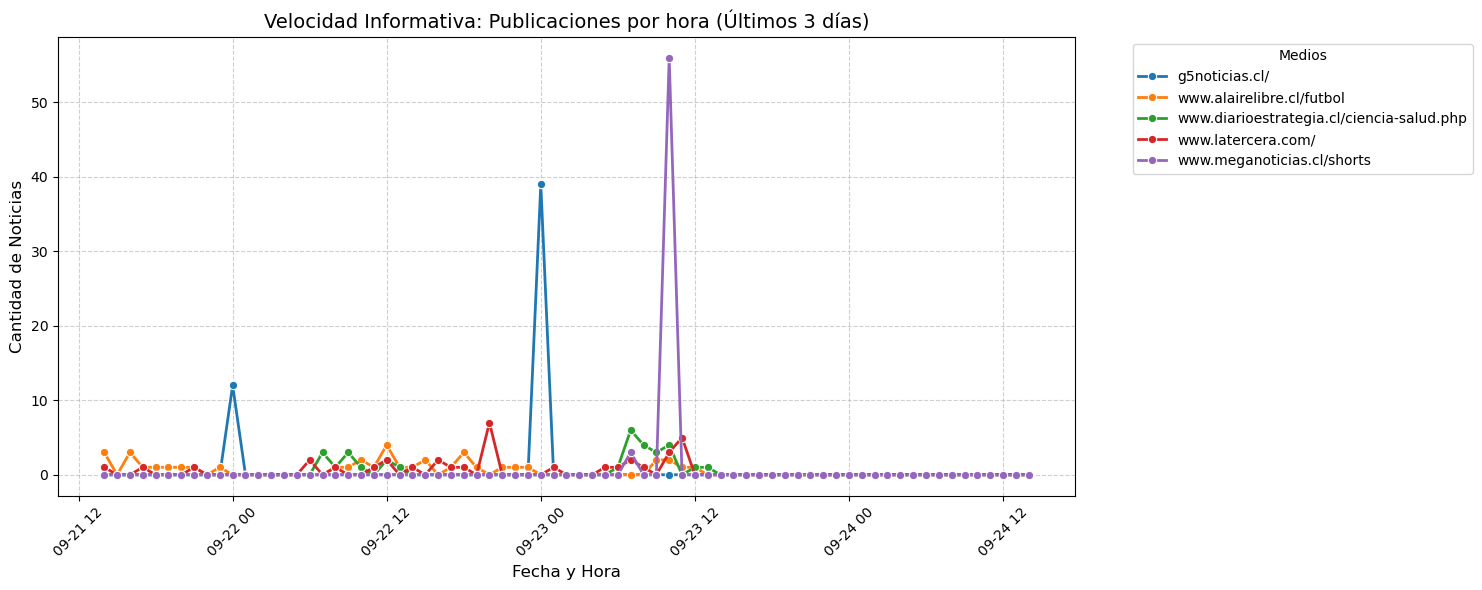

In [12]:
plt.figure(figsize=(15, 6))

# Creamos el gráfico de líneas
sns.lineplot(
    data=df_grafico, 
    x='hour_bucket', 
    y='news_count', 
    hue='media_name', 
    marker='o', # Añade un pequeño punto en cada hora para mayor claridad
    linewidth=2
)

# Ajustes de formato
plt.title('Velocidad Informativa: Publicaciones por hora (Últimos 3 días)', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Cantidad de Noticias', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Medios', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda fuera del gráfico
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Tasa de Duplicación (Syndication Tracker): Porcentaje de noticias duplicadas identificadas 

In [20]:
nlp = spacy.load("es_core_news_lg")

In [72]:
query = "SELECT id, media_name, body, date FROM news_db.news_chile WHERE date >= CURRENT_TIMESTAMP - INTERVAL '3 days' AND date <= CURRENT_TIMESTAMP"
df_results = con.sql(query).fetchdf()

In [73]:
df_results.head()

,id,media_name,body,date
0,917499,lahora.cl/rss/global.xml,"El 10 de noviembre, el Teatro Caupolicán será ...",2026-09-22 00:00:00
1,918616,redgol.cl/colocolo,Arturo Vidal fue uno de los jugadores que apad...,2026-09-23 08:34:50
2,918617,redgol.cl/rss/feed/category/colocolo,Colo Colo sigue con la brújula algo extraviada...,2026-09-22 23:14:21
3,918623,www.redgol.cl/rugby,Colo Colo y Audax Italiano dejaron abierta la ...,2026-09-22 23:55:28
4,918780,www.encancha.cl/,El fútbol transandino sumó un nuevo y particul...,2026-09-22 00:00:00


In [74]:
def get_trigrams_spacy(doc:str) -> list:
    doc = nlp(doc)
    tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]
    trigrams = [
    " ".join((tokens[i], tokens[i + 1], tokens[i + 2])) for i in range(len(tokens) - 2)
    ]
    return trigrams

In [75]:
df_results["trigrams"] = df_results["body"].apply(lambda doc: get_trigrams_spacy(doc))

In [76]:
from datasketch import MinHash, MinHashLSH

df_results = df_results.sort_values(by='date', ascending=True).reset_index(drop=True)

# threshold: 0.8 significa que consideramos duplicado si comparten el 80% o más de sus 3-gramas.
# num_perm: 128 es el estándar. A mayor número, más precisión pero mayor uso de CPU.
UMBRAL_SIMILITUD = 0.85 
NUM_PERMUTACIONES = 128

lsh = MinHashLSH(threshold=UMBRAL_SIMILITUD, num_perm=NUM_PERMUTACIONES)

# Lista para guardar los resultados
is_duplicate_list = []

# 3. PROCESAR CADA NOTICIA
for index, row in df_results.iterrows():
    # Inicializamos el MinHash para la noticia actual
    m = MinHash(num_perm=NUM_PERMUTACIONES)
    
    # Alimentamos el MinHash con los 3-gramas
    for trigram in row['trigrams']:
        m.update(trigram.encode('utf8'))
        
    # Consultamos al LSH si hay alguna noticia similar ya indexada
    # LSH devuelve una lista con los 'id' de las noticias que superan el umbral
    resultados_similares = lsh.query(m)
    
    if len(resultados_similares) > 0:
        # Si encuentra similitudes, es un duplicado/cable de agencia
        is_duplicate_list.append(True)
    else:
        # Si devuelve lista vacía (0), es contenido original
        is_duplicate_list.append(False)
        
    # Insertamos LA NOTICIA ACTUAL al índice LSH para compararla con las del futuro.
    # Se usa el 'id' como llave única en el índice.
    lsh.insert(row['id'], m)

# 4. ASIGNAR LA NUEVA COLUMNA AL DATAFRAME
df_results['is_duplicate'] = is_duplicate_list

# Opcional: Convertir a 1 y 0 en lugar de True/False si lo prefieres para cálculos matemáticos
df_results['is_duplicate_int'] = df_results['is_duplicate'].astype(int)

In [77]:
df_results["is_duplicate"].value_counts()

is_duplicate
False    1852
True      145
Name: count, dtype: int64

In [64]:
df_results.query('is_duplicate_int == 1').sort_values(by=["body"]).head(120)

,id,media_name,body,date,trigrams,is_duplicate,is_duplicate_int
615,933183,www.diarioestrategia.cl/pais.php,(www.camara.cl)\n\nLa Sala de la Cámara de Dip...,2026-09-22 07:14:07,"[www.camara.cl la sala, la sala de, sala de la...",True,1
1657,933181,www.diarioestrategia.cl/pais.php,(www.mop.gob.cl)\n\n“Estamos viendo el avance ...,2026-09-23 07:42:34,"[www.mop.gob.cl estamos viendo, estamos viendo...",True,1
621,933182,www.diarioestrategia.cl/pais.php,(www.senado.cl)\n\nEn el marco de la conmemora...,2026-09-22 07:20:35,"[www.senado.cl en el, en el marco, el marco de...",True,1
1629,920374,www.chanarcillo.cl/category/policial,***Fiscal Sebastián Coya González informó que ...,2026-09-23 06:13:05,"[fiscal sebastián coya, sebastián coya gonzále...",True,1
607,920382,www.chanarcillo.cl/category/policial,*Detenidas 14 personas: 9 extranjeros y 5 chil...,2026-09-22 06:22:33,"[detenidas 14 personas, 14 personas 9, persona...",True,1
...,...,...,...,...,...,...,...
1713,920169,www.maray.cl/category/ciencia-tecnologia,La cuarta transferencia considera más de $3.92...,2026-09-23 08:53:05,"[la cuarta transferencia, cuarta transferencia...",True,1
1982,928593,ovallehoy.cl/,La iniciativa permitió entregar orientación so...,2026-09-23 12:21:20,"[la iniciativa permitió, iniciativa permitió e...",True,1
366,925470,www.chillanonline.cl/V7,La instancia recibió en audiencia a los cinco ...,2026-09-22 00:00:00,"[la instancia recibió, instancia recibió en, r...",True,1
578,919749,www.aricaldia.cl/contacto,La jornada “Hombres por el Cambio” abordó la i...,2026-09-22 01:58:12,"[la jornada hombres, jornada hombres por, homb...",True,1


In [78]:
tasa_global = df_results['is_duplicate_int'].mean() * 100
print(f"Tasa de Duplicación Global: {tasa_global:.1f}%")

Tasa de Duplicación Global: 7.3%


# Anomalías de Longitud

In [79]:
query = "SELECT id, length(body) AS longitud_textos FROM news_db.news_chile WHERE date >= CURRENT_TIMESTAMP - INTERVAL '30 days' AND date <= CURRENT_TIMESTAMP"
df_results = con.sql(query).fetchdf()

In [80]:
df_results

,id,longitud_textos
0,221725,15497
1,223604,3250
2,185658,16708
3,849268,3260
4,716802,2151
...,...,...
24438,720019,2809
24439,720020,3462
24440,720021,2205
24441,720026,3526


In [81]:
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print('=== Percentiles de longitud de textos (caracteres) ===')
for p in percentiles:
    print(f'{p:2d}° percentil: {df_results["longitud_textos"].quantile(p/100):.0f}')

=== Percentiles de longitud de textos (caracteres) ===
 1° percentil: 1866
 5° percentil: 2019
10° percentil: 2127
25° percentil: 2461
50° percentil: 3216
75° percentil: 4514
90° percentil: 6353
95° percentil: 8535
99° percentil: 15488
